<a href="https://colab.research.google.com/github/bharath-0905/mlproject/blob/main/airline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME']="Bharath20"
os.environ['kaggle_key']="KGAT_10c8f629b88da2dac16c940f033b02cc"

In [ ]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
dataset-for-dbscan.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [ ]:
# load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
print(df.head())

     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [8]:
data =df['Passengers'].values.reshape(-1,1)

In [15]:
import numpy as np
import numpy as np
# create sequences
def create_sequences(dataset, time_steps=10):
    X, y = [],[]
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i + time_steps, 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

# Scale the data
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

time_steps = 10
X, y = create_sequences(data_scaled, time_steps)

In [20]:
#Step 4: Build RNN Model

model = Sequential([

    SimpleRNN(50, activation='tanh', input_shape=(time_steps,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Example: assume X and y are already prepared
X = np.array(X)   # shape (samples, timesteps, features)
y = np.array(y)   # shape (samples,)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape labels to (n_samples, 1) for regression/binary classification
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# Build model
model = Sequential()
# LSTM expects input shape: (samples, timesteps, features)
if X_train.ndim == 2:
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
if X_test.ndim == 2:
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))  # single output per sample

# Compile with appropriate loss
# Use 'mse' for regression, 'binary_crossentropy' for binary classification
model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

# Train
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Train: (107, 10) (107, 1)
Test: (27, 10) (27, 1)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.1234 - mae: 0.2819 - val_loss: 0.0270 - val_mae: 0.1153
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0251 - mae: 0.1193 - val_loss: 0.0155 - val_mae: 0.1117
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0231 - mae: 0.1346 - val_loss: 0.0186 - val_mae: 0.1233
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0154 - mae: 0.1023 - val_loss: 0.0091 - val_mae: 0.0663
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0152 - mae: 0.0897 - val_loss: 0.0092 - val_mae: 0.0631
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0143 - mae: 0.0874 - val_loss: 0.0089 - val_mae: 0.0695
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0127 - mae: 0.0889 - val_loss: 0.0101 - val_mae: 0.0803
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0126 - mae: 0.0887 - val_loss: 0.0091 - val_mae: 0.0728
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0120 - mae: 0.0849 - val_loss: 0

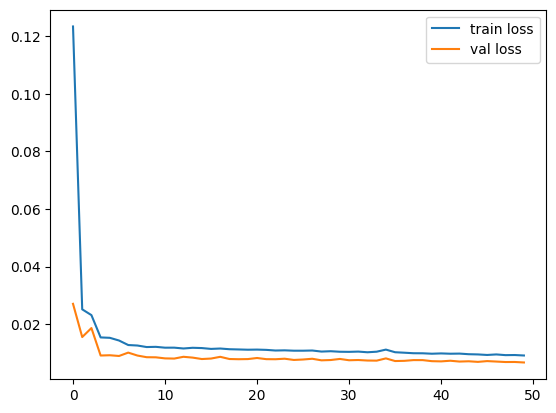

In [28]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [31]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


In [32]:
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

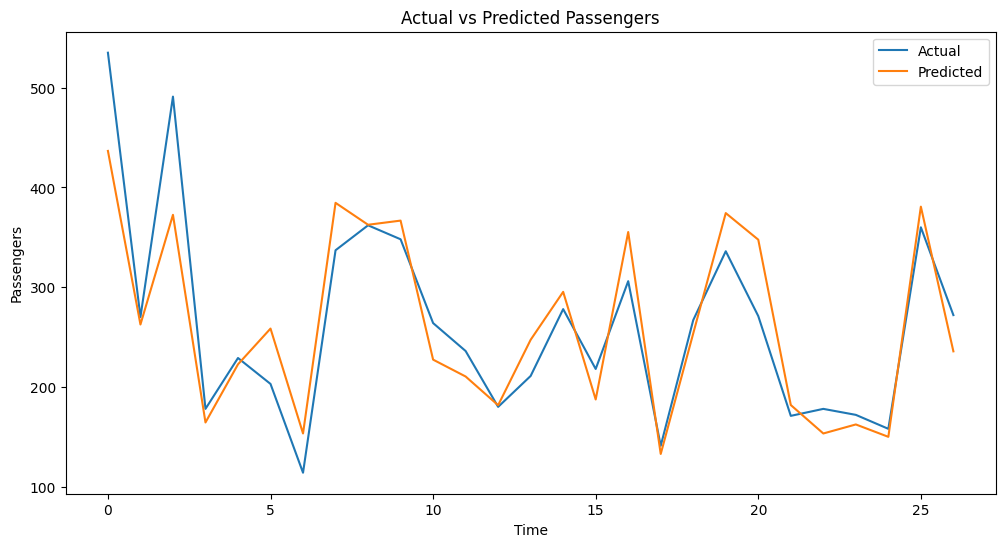

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Actual vs Predicted Passengers')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()
plt.show()

In [35]:
last_sequence = data_scaled[-time_steps:]  # last 10 time steps
last_sequence = last_sequence.reshape(1,time_steps,1 )
next_value = model.predict(last_sequence)
next_value_inv = scaler.inverse_transform(next_value)
print("Predicted next passenger count:",scaler.inverse_transform(next_value)[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted next passenger count: 463.82953
